## Load the dataset

In [2]:
import os
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports/metrics", exist_ok=True)

In [3]:
import pandas as pd
import numpy as np


df = pd.read_csv("../data/raw/Diabetes_Final_Data_V2.csv")

print("Rows and columns:", df.shape)
display(df.head())
display(df.tail())

Rows and columns: (5437, 15)


,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
5432,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5433,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5434,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5435,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No
5436,26,Female,80,134,93,5.15,1.47,67.1,30.92,0,0,0,0,0,No


#### Inspect structure

In [4]:
print(df.info())
print(df.columns.tolist())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5437 entries, 0 to 5436
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5437 non-null   int64  
 1   gender                  5437 non-null   object 
 2   pulse_rate              5437 non-null   int64  
 3   systolic_bp             5437 non-null   int64  
 4   diastolic_bp            5437 non-null   int64  
 5   glucose                 5437 non-null   float64
 6   height                  5437 non-null   float64
 7   weight                  5437 non-null   float64
 8   bmi                     5437 non-null   float64
 9   family_diabetes         5437 non-null   int64  
 10  hypertensive            5437 non-null   int64  
 11  family_hypertension     5437 non-null   int64  
 12  cardiovascular_disease  5437 non-null   int64  
 13  stroke                  5437 non-null   int64  
 14  diabetic                5437 non-null   

In [5]:
#Check the target:
print(df["diabetic"].value_counts(dropna=False))
print(df["diabetic"].value_counts(normalize=True))

diabetic
No     5093
Yes     344
Name: count, dtype: int64
diabetic
No     0.93673
Yes    0.06327
Name: proportion, dtype: float64


In [6]:
if pd.api.types.is_numeric_dtype(df["diabetic"]):
    df["diabetic"] = df["diabetic"].astype(int)
else:
    df["diabetic"] = (
        df["diabetic"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"no": 0, "yes": 1})
    )

assert df["diabetic"].notna().all()
print(df["diabetic"].value_counts(normalize=True))
print("Rows and columns:", df.shape)


diabetic
0    0.93673
1    0.06327
Name: proportion, dtype: float64
Rows and columns: (5437, 15)


In [7]:
assert df["diabetic"].notna().all()
print(df["diabetic"].value_counts())

diabetic
0    5093
1     344
Name: count, dtype: int64


#### Data-quality checks
 

In [8]:
#Missing values

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_table)

,missing_count,missing_percent
age,0,0.0
gender,0,0.0
pulse_rate,0,0.0
systolic_bp,0,0.0
diastolic_bp,0,0.0
glucose,0,0.0
height,0,0.0
weight,0,0.0
bmi,0,0.0
family_diabetes,0,0.0


In [9]:
#Duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
#Unique categorical values

for column in df.select_dtypes(include="object").columns:
    print(column, df[column].unique())

gender ['Female' 'Male']


##  Exploratory data analysis

#### Class distribution

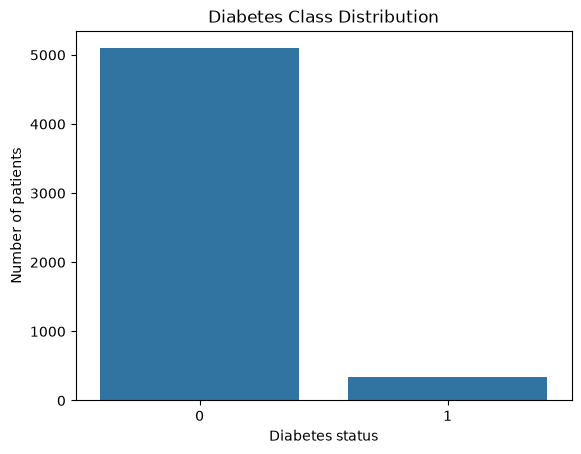

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="diabetic")
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes status")
plt.ylabel("Number of patients")
plt.show()

#### Numerical distributions


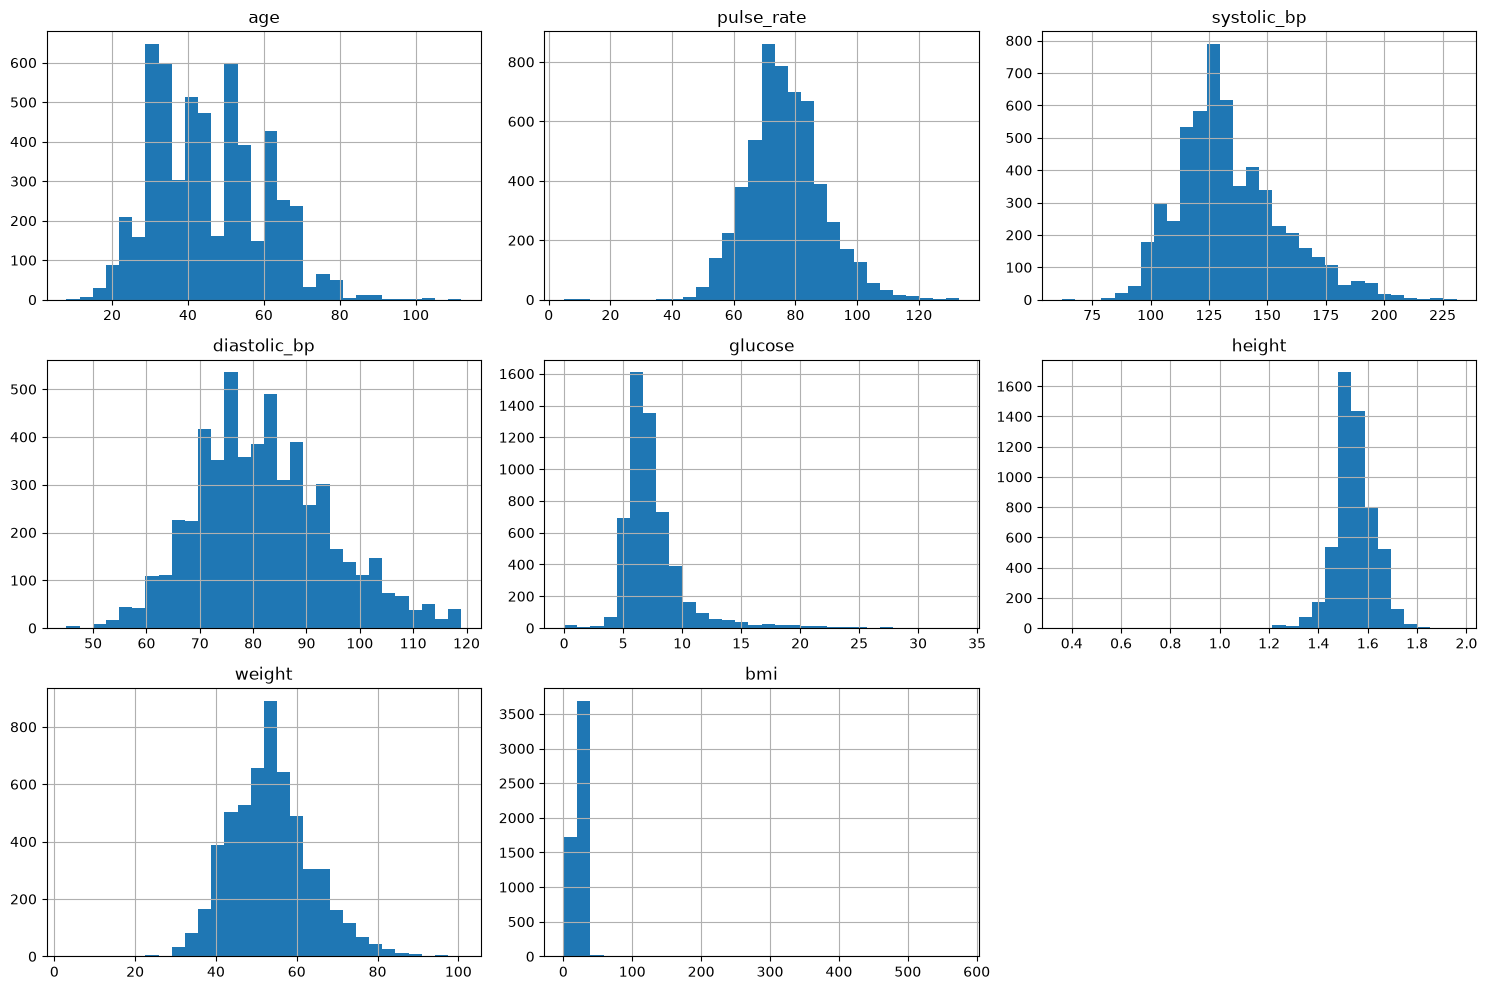

In [12]:
numerical_columns = [
    "age",
    "pulse_rate",
    "systolic_bp",
    "diastolic_bp",
    "glucose",
    "height",
    "weight",
    "bmi"
]

df[numerical_columns].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

#### Group comparison


In [13]:
display(
    df.groupby("diabetic")[numerical_columns]
      .agg(["count", "mean", "median", "std"])
      .T
)

diabetic                       0           1
age          count   5093.000000  344.000000
             mean      45.207736   50.360465
             median    45.000000   50.000000
             std       14.396270   12.195361
pulse_rate   count   5093.000000  344.000000
             mean      76.622030   78.944767
             median    76.000000   78.000000
             std       12.193738   13.469753
systolic_bp  count   5093.000000  344.000000
             mean     132.960338  147.177326
             median   129.000000  145.000000
             std       21.981362   22.657945
diastolic_bp count   5093.000000  344.000000
             mean      81.556057   89.595930
             median    80.000000   90.000000
             std       12.320169   12.574540
glucose      count   5093.000000  344.000000
             mean       7.308677   10.975581
             median     6.840000    9.280000
             std        2.510316    5.406595
height       count   5093.000000  344.000000
             mean       1.547870    1.558953
             median     1.550000    1.570000
             std        0.079475    0.099916
weight       count   5093.000000  344.000000
             mean      53.343177   57.826163
             median    52.600000   57.100000
             std       10.036094    9.991312
bmi          count   5093.000000  344.000000
             mean      22.374869   23.914797
             median    21.800000   23.205000
             std        8.986258    4.510114

#### Boxplots by diabetes status


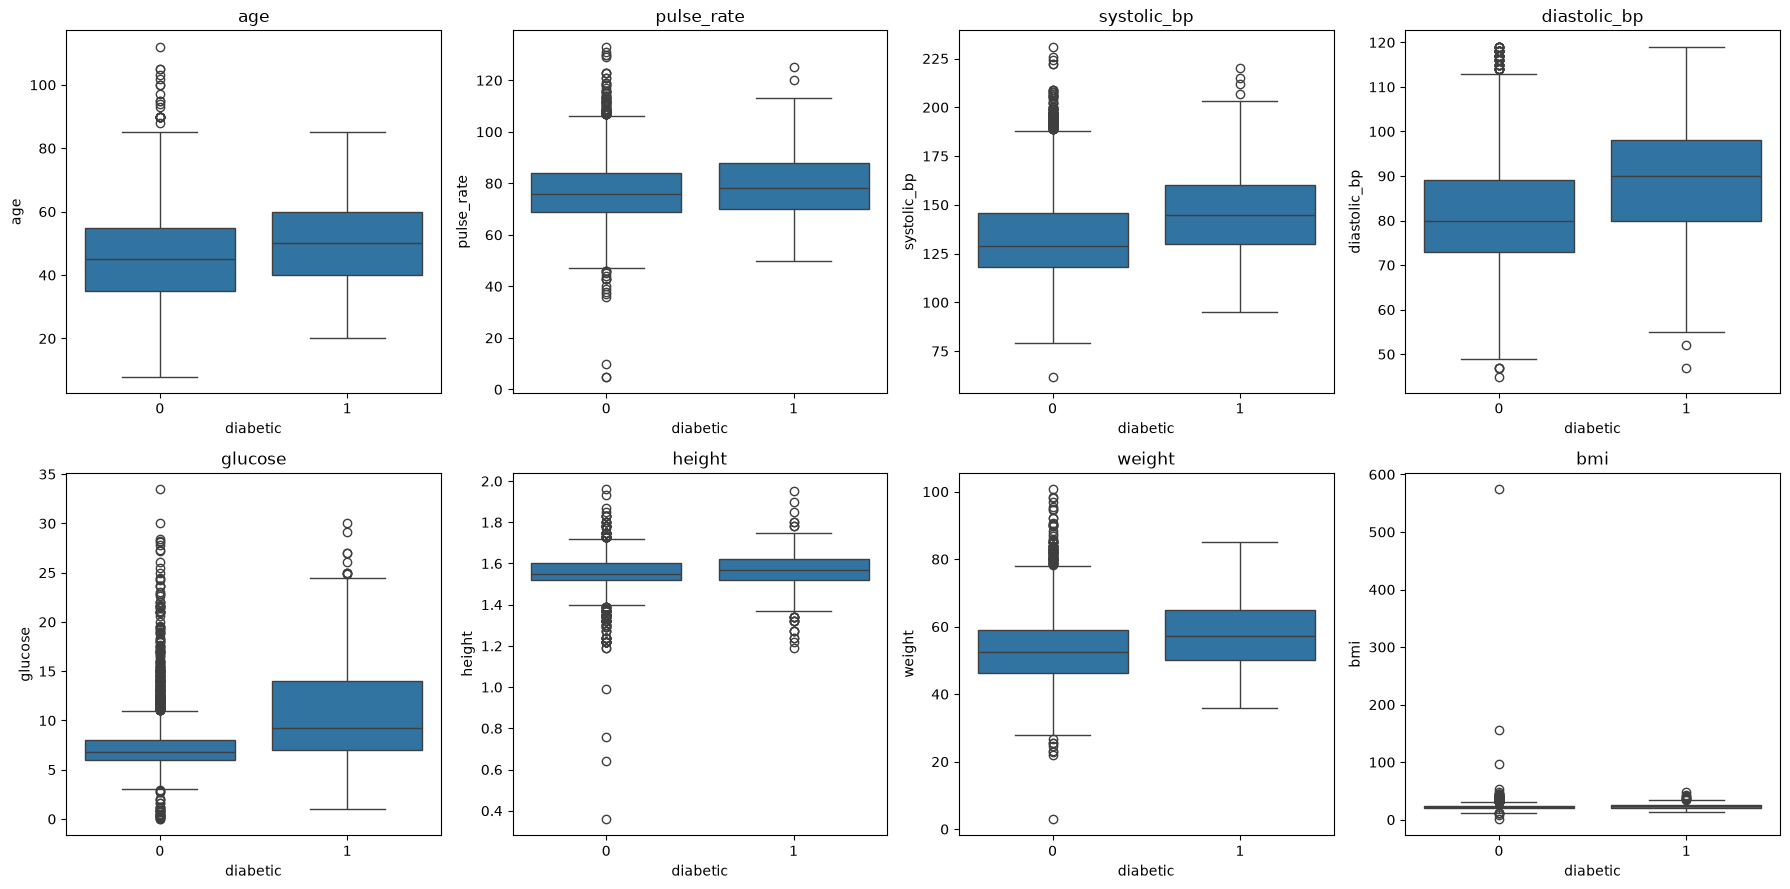

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, column in zip(axes.ravel(), numerical_columns):
    sns.boxplot(
        data=df,
        x="diabetic",
        y=column,
        ax=ax
    )
    ax.set_title(column)

plt.tight_layout()
plt.show()

#### Correlation analysis


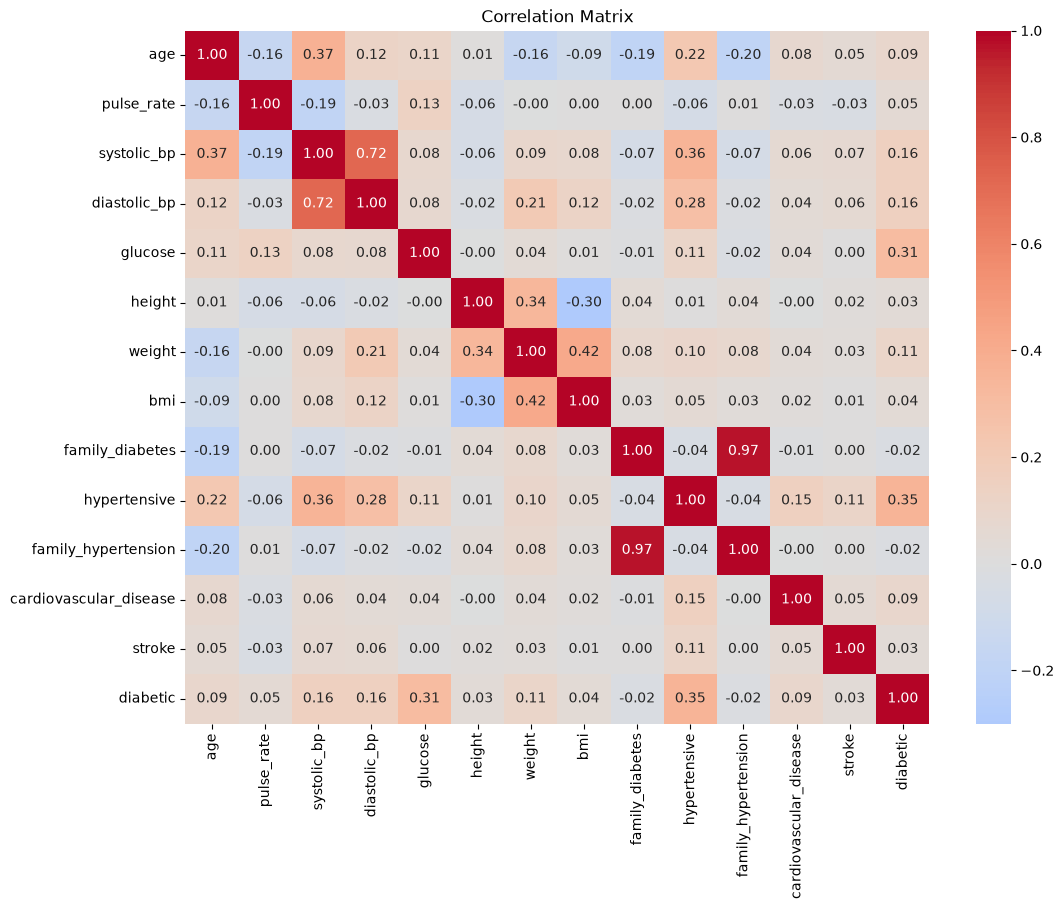

In [15]:
plt.figure(figsize=(12, 9))

correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Investigate suspicious values

In [16]:
checks = {
    "age_less_than_18": df["age"] < 18,
    "age_greater_than_100": df["age"] > 100,
    "pulse_less_than_40": df["pulse_rate"] < 40,
    "pulse_greater_than_200": df["pulse_rate"] > 200,
    "systolic_out_of_range": (df["systolic_bp"] < 70) | (df["systolic_bp"] > 200),
    "diastolic_out_of_range": (df["diastolic_bp"] < 40) | (df["diastolic_bp"] > 130),
    "glucose_le_zero": df["glucose"] <= 0,
    "height_less_than_1_metre": df["height"] < 1.0,
    "weight_less_than_20": df["weight"] < 20,
    "bmi_less_than_10": df["bmi"] < 10,
    "bmi_greater_than_60": df["bmi"] > 60,
}

for name, condition in checks.items():
    print(name, condition.sum())

outlier_mask = pd.concat(checks.values(), axis=1).any(axis=1)
print("\nTotal flagged rows:", outlier_mask.sum(), "out of", len(df))
display(df[outlier_mask].head(20))

age_less_than_18 14
age_greater_than_100 5
pulse_less_than_40 7
pulse_greater_than_200 0
systolic_out_of_range 32
diastolic_out_of_range 0
glucose_le_zero 1
height_less_than_1_metre 4
weight_less_than_20 1
bmi_less_than_10 2
bmi_greater_than_60 3

Total flagged rows: 65 out of 5437


,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
25,60,Male,57,226,115,5.99,1.65,51.3,18.82,0,1,0,0,0,0
30,55,Female,72,209,118,7.90,1.42,50.0,24.71,0,0,0,0,0,0
35,52,Female,69,212,110,6.21,1.32,60.0,34.39,0,1,0,1,0,1
66,52,Female,92,207,98,6.00,1.77,51.0,16.28,0,0,0,0,0,0
71,20,Female,97,123,83,7.01,0.76,55.9,96.27,0,0,0,0,0,0
157,24,Male,63,165,89,4.89,0.36,72.6,574.13,0,0,0,0,0,0
360,90,Female,60,222,111,7.58,1.60,58.2,22.73,0,1,0,0,0,0
371,15,Female,89,134,83,5.00,1.52,45.0,19.48,0,0,1,0,0,0
412,65,Female,58,222,95,8.12,1.57,58.0,23.39,0,1,0,0,0,0
415,46,Female,74,202,106,4.29,1.55,61.0,25.41,0,1,0,0,1,0


#### Cleaning rule

In [17]:
df_clean = df.loc[~outlier_mask].reset_index(drop=True)
print("Before:", df.shape, "After:", df_clean.shape)
print(df_clean["diabetic"].value_counts(normalize=True))

print("Duplicates after cleaning:", df_clean.duplicated().sum())
print(df_clean.isna().sum().sum(), "missing values after cleaning")

Before: (5437, 15) After: (5372, 15)
diabetic
0    0.937453
1    0.062547
Name: proportion, dtype: float64
Duplicates after cleaning: 0
0 missing values after cleaning


##  Check BMI consistency

In [18]:
#Because BMI is derived from weight and height:

bmi_calculated = df_clean["weight"] / (df_clean["height"] ** 2)
bmi_diff = (df_clean["bmi"] - bmi_calculated).abs()
print(bmi_diff.describe())
print("Rows with bmi_diff > 1:", (bmi_diff > 1).sum())

count    5.372000e+03
mean     7.162852e-02
std      5.252848e-02
min      3.552714e-15
25%      1.861602e-02
50%      7.644687e-02
75%      1.169252e-01
max      3.354943e-01
dtype: float64
Rows with bmi_diff > 1: 0


##  EDA: After

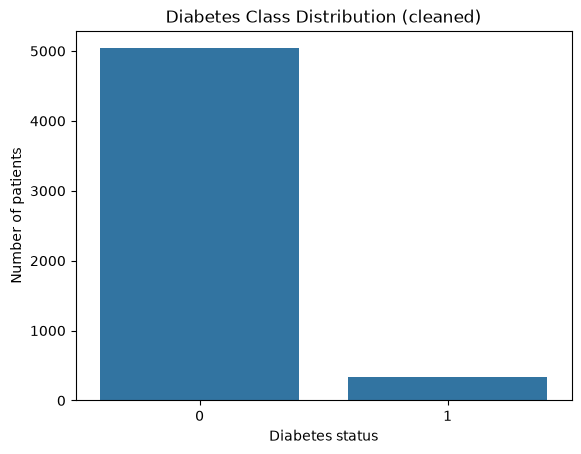

In [19]:
#class distributions
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_clean, x="diabetic")
plt.title("Diabetes Class Distribution (cleaned)")
plt.xlabel("Diabetes status")
plt.ylabel("Number of patients")
plt.savefig("../reports/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

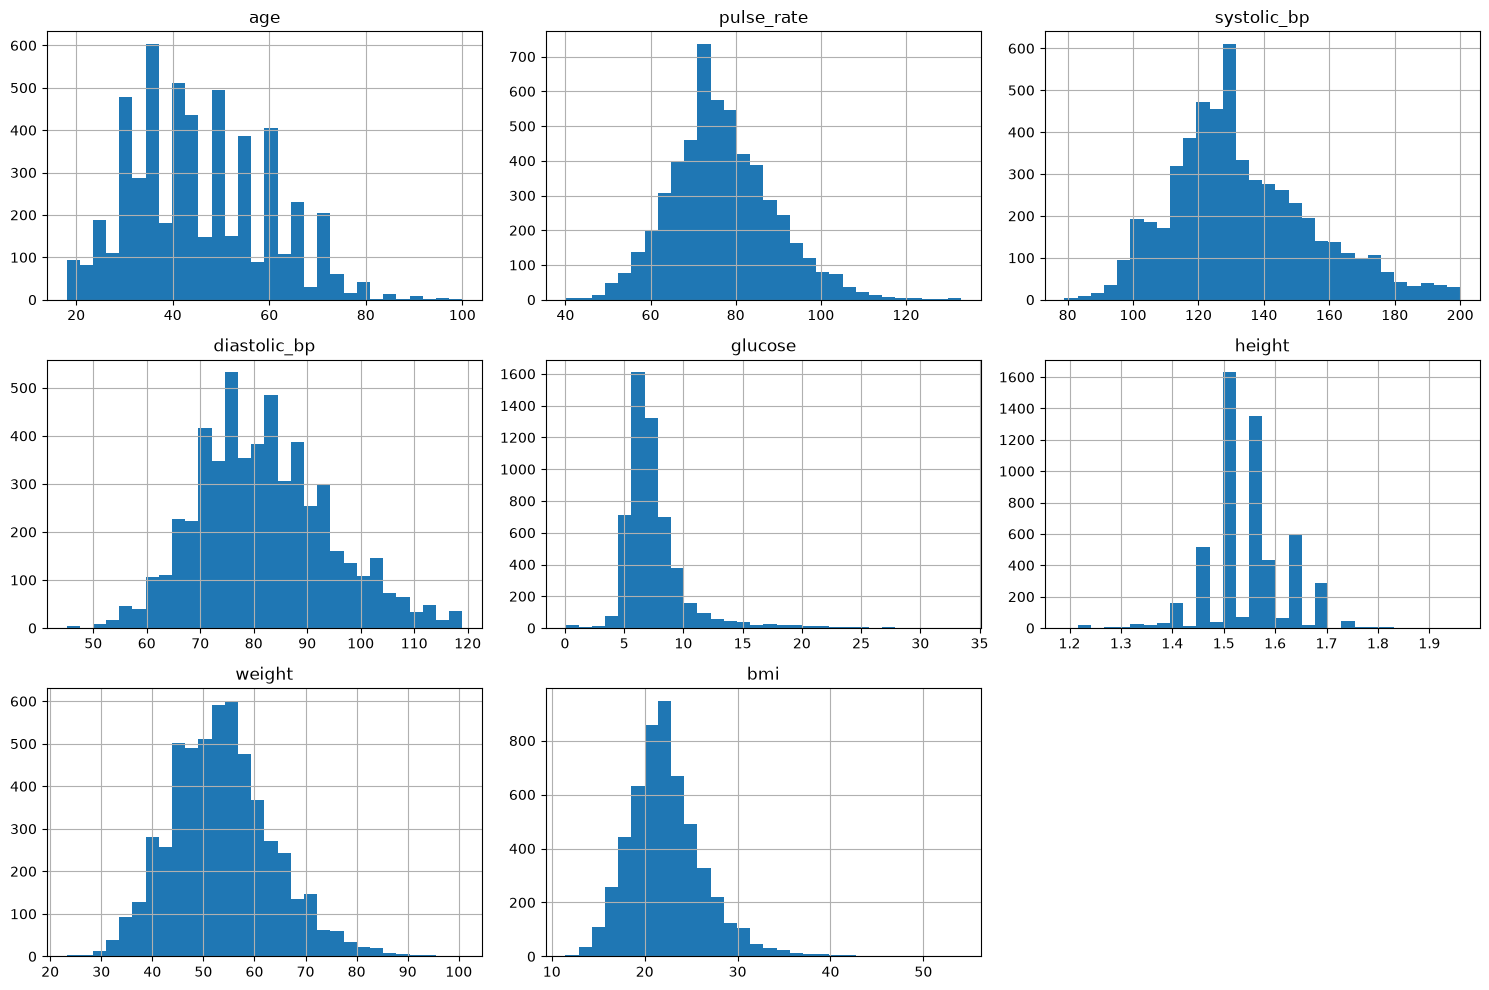

In [20]:
#numerical histograms
numerical_columns = [
    "age", "pulse_rate", "systolic_bp", "diastolic_bp",
    "glucose", "height", "weight", "bmi"
]

df_clean[numerical_columns].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.savefig("../reports/figures/numerical_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


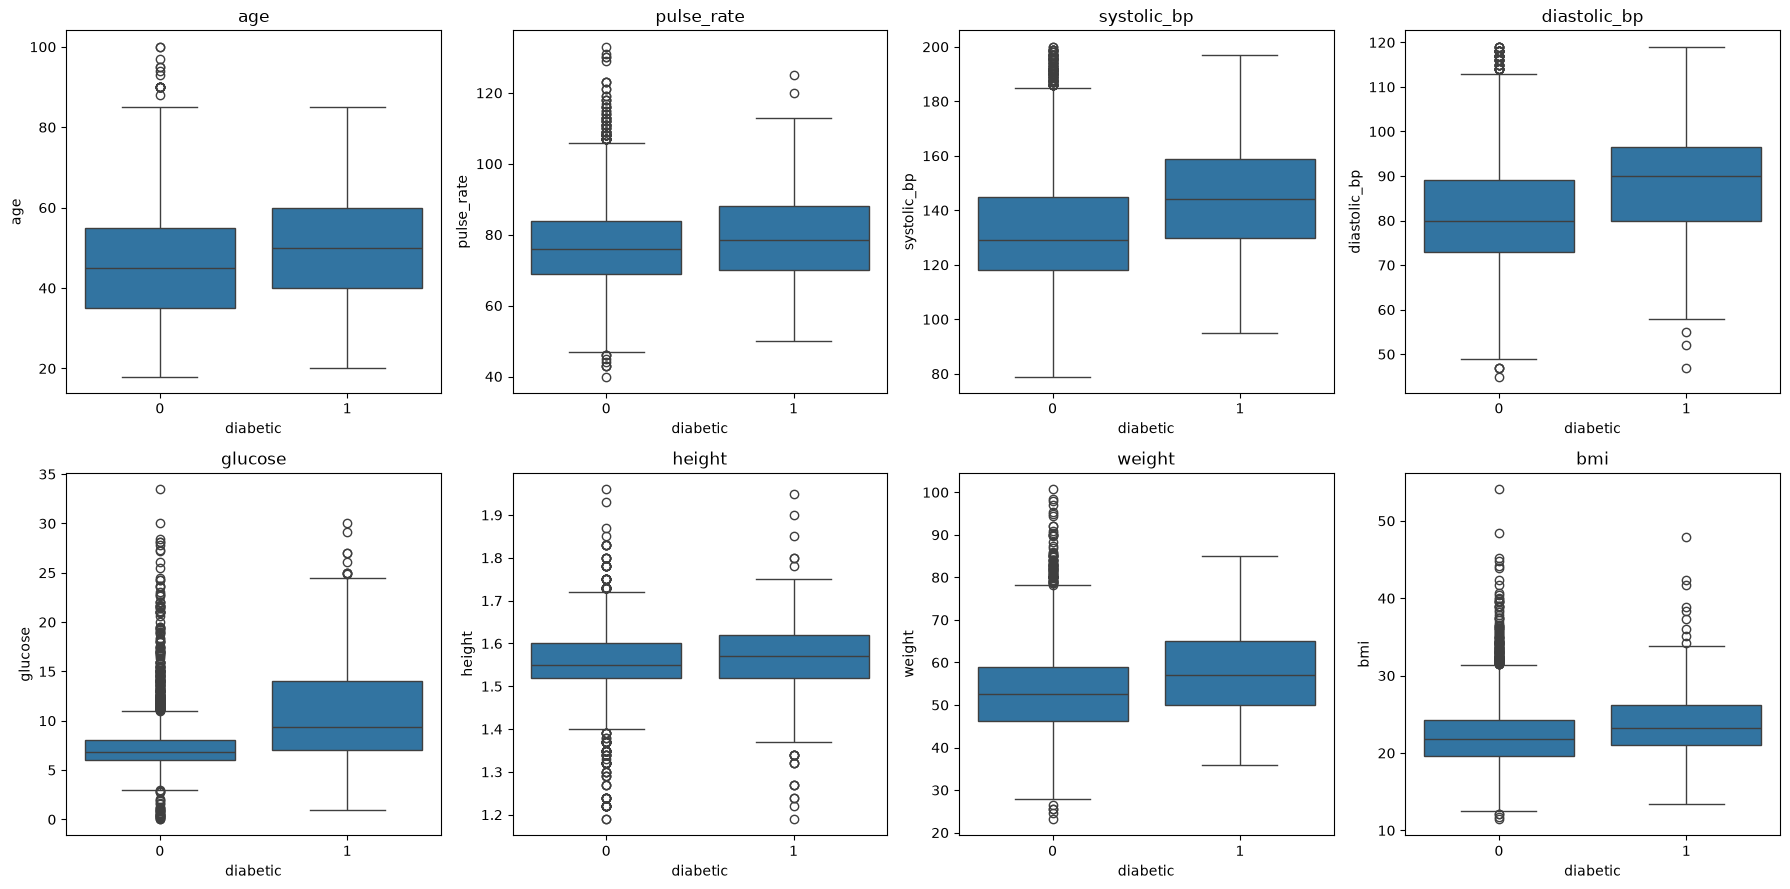

In [21]:
#boxplots by status

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, column in zip(axes.ravel(), numerical_columns):
    sns.boxplot(data=df_clean, x="diabetic", y=column, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.savefig("../reports/figures/boxplots_by_status.png", dpi=150, bbox_inches="tight")
plt.show()

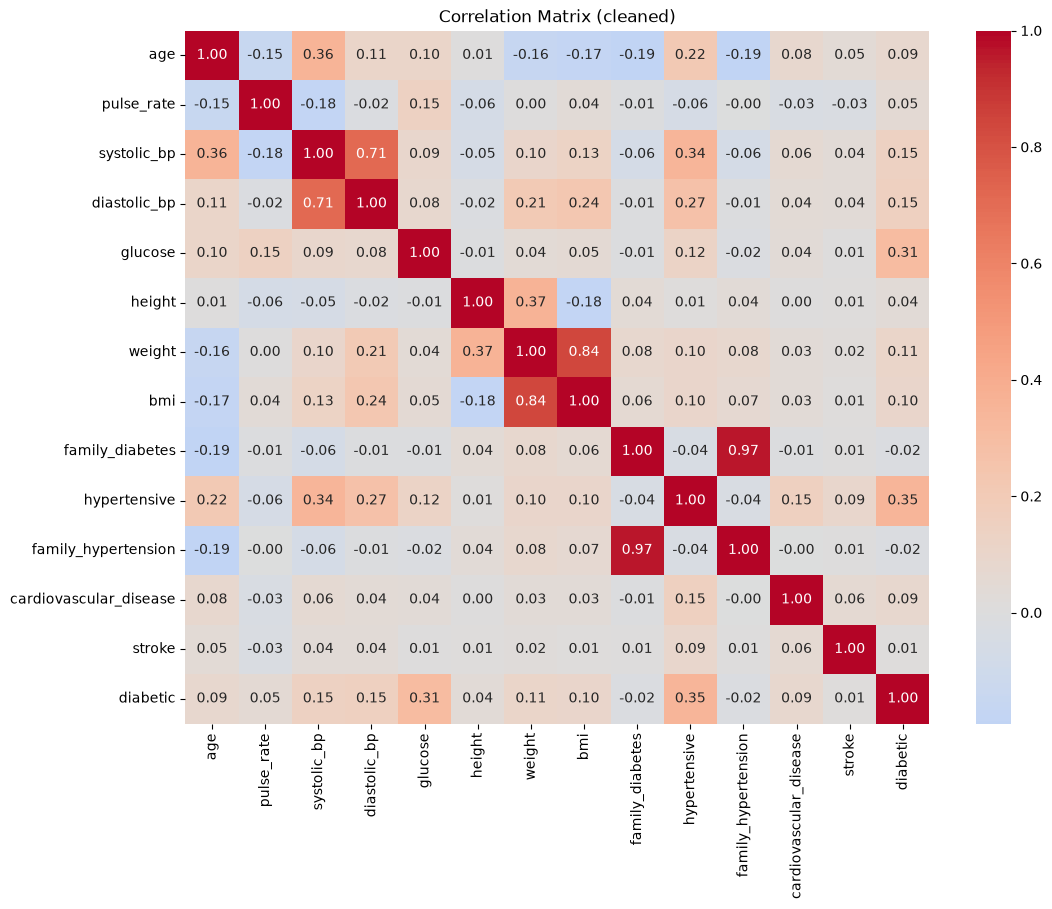

In [22]:
#correlation heatmap
import numpy as np

plt.figure(figsize=(12, 9))
correlation_matrix = df_clean.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (cleaned)")
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
#Save the cleaned/processed dataset
df_clean.to_csv("../data/processed/diabetes_clean.csv", index=False)
print("Saved processed dataset:", df_clean.shape)

Saved processed dataset: (5372, 15)


## Split

In [24]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns="diabetic")
y = df_clean["diabetic"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(4297, 14) (1075, 14)


## Preprocessors

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_features = ["gender"]
numerical_features = [
    "age", "pulse_rate", "systolic_bp", "diastolic_bp",
    "glucose", "height", "weight", "bmi",
    "family_diabetes", "hypertensive", "family_hypertension",
    "cardiovascular_disease", "stroke"
]

numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_logistic = ColumnTransformer([
    ("numeric", numeric_scaled, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
preprocessor_tree = ColumnTransformer([
    ("numeric", numeric_unscaled, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

### Fit-check the preprocessor

In [26]:
X_train_t = preprocessor_logistic.fit_transform(X_train)
X_test_t = preprocessor_logistic.transform(X_test)
print("Transformed shapes:", X_train_t.shape, X_test_t.shape)

X_train_dense = X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t
print("Any NaNs left:", np.isnan(X_train_dense).sum())

Transformed shapes: (4297, 15) (1075, 15)
Any NaNs left: 0


## Baseline: Logistic Regression

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor_logistic),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

param_grid = [
    {
        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "liblinear"]
    },
    {
        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["liblinear"]
    },
    {
        "model__penalty": ["elasticnet"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__solver": ["saga"]
    }
]

search_lr = GridSearchCV(
    logreg_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

search_lr.fit(X_train, y_train)

print("Best params:", search_lr.best_params_)
print("Best CV ROC-AUC:", search_lr.best_score_)

logreg_pipeline = search_lr.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.8689852905471206


c:\Users\vishnu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [28]:
# Evaluate the tuned Logistic Regression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

y_prob_lr = logreg_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = logreg_pipeline.predict(X_test)

metrics_lr = {
    "roc_auc": roc_auc_score(y_test, y_prob_lr),
    "pr_auc": average_precision_score(y_test, y_prob_lr),
    "best_params": search_lr.best_params_,
    "cv_roc_auc": search_lr.best_score_
}
print(metrics_lr)
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

{'roc_auc': 0.8560619521440417, 'pr_auc': 0.41706774222103643, 'best_params': {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}, 'cv_roc_auc': np.float64(0.8689852905471206)}
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      1008
           1       0.22      0.81      0.34        67

    accuracy                           0.81      1075
   macro avg       0.60      0.81      0.62      1075
weighted avg       0.94      0.81      0.85      1075

[[814 194]
 [ 13  54]]


## Comparison model: XGBoost

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

xgb_pipeline = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}
Best CV ROC-AUC: 0.8854969211742347


In [30]:
#Evaluate the tuned model

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_pipeline.predict(X_test)

metrics_xgb = {
    "roc_auc": roc_auc_score(y_test, y_prob_xgb),
    "pr_auc": average_precision_score(y_test, y_prob_xgb),
    "best_params": search.best_params_,
    "cv_roc_auc": search.best_score_
}
print(metrics_xgb)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

{'roc_auc': 0.8814706230751007, 'pr_auc': 0.4828563278599914, 'best_params': {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}, 'cv_roc_auc': np.float64(0.8854969211742347)}
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      1008
           1       0.27      0.75      0.40        67

    accuracy                           0.86      1075
   macro avg       0.63      0.81      0.66      1075
weighted avg       0.94      0.86      0.89      1075

[[873 135]
 [ 17  50]]


## ROC comparison plot

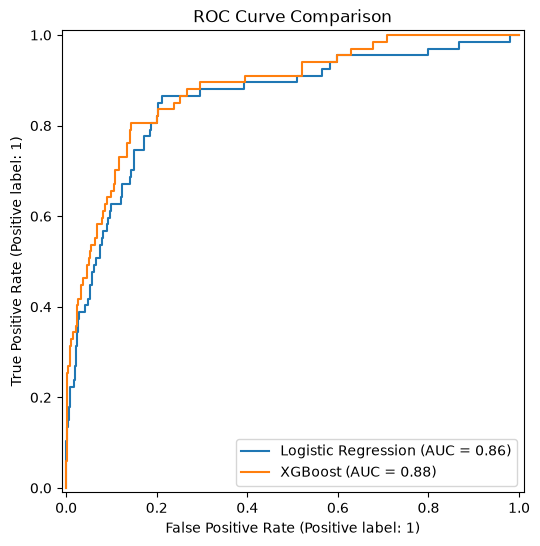

In [31]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=ax)
plt.title("ROC Curve Comparison")
plt.savefig("../reports/figures/roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
#save model + metrics
import joblib
import json

results = {"logistic_regression": metrics_lr, "xgboost": metrics_xgb}
best_name = max(results, key=lambda k: results[k]["roc_auc"])
best_pipeline = logreg_pipeline if best_name == "logistic_regression" else xgb_pipeline

print("Best model:", best_name, results[best_name])

joblib.dump(best_pipeline, "../models/diabetes_pipeline.joblib")

with open("../reports/metrics/model_comparison.json", "w") as f:
    json.dump(results, f, indent=2)

Best model: xgboost {'roc_auc': 0.8814706230751007, 'pr_auc': 0.4828563278599914, 'best_params': {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}, 'cv_roc_auc': np.float64(0.8854969211742347)}


In [33]:
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

In [34]:
feature_names = preprocessor_logistic.get_feature_names_out()
print(feature_names)

['numeric__age' 'numeric__pulse_rate' 'numeric__systolic_bp'
 'numeric__diastolic_bp' 'numeric__glucose' 'numeric__height'
 'numeric__weight' 'numeric__bmi' 'numeric__family_diabetes'
 'numeric__hypertensive' 'numeric__family_hypertension'
 'numeric__cardiovascular_disease' 'numeric__stroke'
 'categorical__gender_Female' 'categorical__gender_Male']
